### Data Understanding

**Goal**:  
Understand the structure, quality, and key patterns in the dataset before building product metrics (LTV, CAC, churn, etc.)

In [1]:
# Set working directory
import local_config
from local_config import directory_path
import os
os.chdir(directory_path)

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# display settings
pd.set_option('display.max_columns', None)

In [2]:
# Load data
accounts = pd.read_csv('data/accounts.csv')
subscriptions = pd.read_csv('data/subscriptions.csv')
feature_usage = pd.read_csv('data/feature_usage.csv')
support_tickets = pd.read_csv('data/support_tickets.csv')
churn_events = pd.read_csv('data/churn_events.csv')


### Initial Overview

#### Shape & Preview
Check dataset sizes and preview records.

In [3]:
accounts.shape
accounts.head()

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,False,False
3,A-1f0ac7,Company_3,HealthTech,UK,2023-08-27,other,Basic,24,True,False
4,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,False,True


Accounts dataset: (500, 10)

In [4]:
subscriptions.shape
subscriptions.head()

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True
1,S-0f6f44,A-9b9fe9,2024-06-11,NaN,Pro,17,833,9996,False,False,False,False,monthly,True
2,S-51c0d1,A-659280,2024-11-25,NaN,Enterprise,62,0,0,True,True,False,False,annual,False
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True
4,S-cff5a2,A-ba6516,2024-01-10,NaN,Enterprise,27,5373,64476,False,False,False,False,monthly,True


Subscriptions dataset: (5000, 14)

The number of subscription records significantly exceeds the number of accounts,
which suggests multiple subscription lifecycle events per account 
(e.g., renewals, upgrades, downgrades).

In [5]:
feature_usage.shape
feature_usage.head()

,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
0,U-1c6c24,S-0fcf7d,2023-07-27,feature_20,9,5004,0,False
1,U-f07cb8,S-c25263,2023-08-07,feature_5,9,369,0,False
2,U-096807,S-f29e7f,2023-12-07,feature_3,9,1458,0,False
3,U-6b1580,S-be655e,2024-07-28,feature_40,5,2085,0,False
4,U-720a29,S-f9b1d0,2024-12-02,feature_12,12,900,0,False


Feature usage dataset: (25000, 8)

In [6]:
support_tickets.shape
support_tickets.head()

,ticket_id,account_id,submitted_at,closed_at,resolution_time_hours,priority,first_response_time_minutes,satisfaction_score,escalation_flag
0,T-0024de,A-712f1c,2023-07-27,2023-07-28 03:00:00,27.0,high,74,NaN,False
1,T-4d04b9,A-e43bf7,2024-07-08,2024-07-09 03:00:00,27.0,urgent,144,NaN,False
2,T-d5e12f,A-0f3e88,2024-10-17,2024-10-17 19:00:00,19.0,urgent,93,4.0,False
3,T-dfce9a,A-4c56c9,2024-09-08,2024-09-09 23:00:00,47.0,medium,126,5.0,False
4,T-c59f77,A-6f8ad2,2024-11-30,2024-12-01 02:00:00,26.0,medium,8,NaN,False


Support tickets dataset: (2000, 9)

In [7]:
churn_events.shape
churn_events.head()

,churn_event_id,account_id,churn_date,reason_code,refund_amount_usd,preceding_upgrade_flag,preceding_downgrade_flag,is_reactivation,feedback_text
0,C-816288,A-c37cab,2024-10-27,pricing,4.03,False,False,False,switched to competitor
1,C-5a81e7,A-37f969,2024-06-25,support,96.45,True,False,False,NaN
2,C-a174be,A-b07346,2024-11-12,budget,0.00,False,False,False,missing features
3,C-accb39,A-1e50e0,2023-11-01,budget,54.94,False,False,False,switched to competitor
4,C-92f889,A-956988,2024-12-30,unknown,0.00,False,True,True,too expensive


Churn events dataset: (600, 9)

### Columns & Data Types
Inspect column types and identify fields that require transformation.

In [8]:
accounts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   account_id       500 non-null    object
 1   account_name     500 non-null    object
 2   industry         500 non-null    object
 3   country          500 non-null    object
 4   signup_date      500 non-null    object
 5   referral_source  500 non-null    object
 6   plan_tier        500 non-null    object
 7   seats            500 non-null    int64 
 8   is_trial         500 non-null    bool  
 9   churn_flag       500 non-null    bool  
dtypes: bool(2), int64(1), object(7)
memory usage: 32.4+ KB


`signup_date` is stored as an object and should be converted to datetime.

In [9]:
subscriptions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subscription_id    5000 non-null   object
 1   account_id         5000 non-null   object
 2   start_date         5000 non-null   object
 3   end_date           486 non-null    object
 4   plan_tier          5000 non-null   object
 5   seats              5000 non-null   int64 
 6   mrr_amount         5000 non-null   int64 
 7   arr_amount         5000 non-null   int64 
 8   is_trial           5000 non-null   bool  
 9   upgrade_flag       5000 non-null   bool  
 10  downgrade_flag     5000 non-null   bool  
 11  churn_flag         5000 non-null   bool  
 12  billing_frequency  5000 non-null   object
 13  auto_renew_flag    5000 non-null   bool  
dtypes: bool(5), int64(3), object(6)
memory usage: 376.1+ KB


`start_date` and `end_date` should be converted to datetime.

In [10]:
feature_usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   usage_id             25000 non-null  object
 1   subscription_id      25000 non-null  object
 2   usage_date           25000 non-null  object
 3   feature_name         25000 non-null  object
 4   usage_count          25000 non-null  int64 
 5   usage_duration_secs  25000 non-null  int64 
 6   error_count          25000 non-null  int64 
 7   is_beta_feature      25000 non-null  bool  
dtypes: bool(1), int64(3), object(4)
memory usage: 1.4+ MB


`usage_date` should be converted to datetime.

In [11]:
support_tickets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ticket_id                    2000 non-null   object 
 1   account_id                   2000 non-null   object 
 2   submitted_at                 2000 non-null   object 
 3   closed_at                    2000 non-null   object 
 4   resolution_time_hours        2000 non-null   float64
 5   priority                     2000 non-null   object 
 6   first_response_time_minutes  2000 non-null   int64  
 7   satisfaction_score           1175 non-null   float64
 8   escalation_flag              2000 non-null   bool   
dtypes: bool(1), float64(2), int64(1), object(5)
memory usage: 127.1+ KB


`submitted_at` and `closed_at` should be converted to datetime.

In [12]:
churn_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   churn_event_id            600 non-null    object 
 1   account_id                600 non-null    object 
 2   churn_date                600 non-null    object 
 3   reason_code               600 non-null    object 
 4   refund_amount_usd         600 non-null    float64
 5   preceding_upgrade_flag    600 non-null    bool   
 6   preceding_downgrade_flag  600 non-null    bool   
 7   is_reactivation           600 non-null    bool   
 8   feedback_text             452 non-null    object 
dtypes: bool(3), float64(1), object(5)
memory usage: 30.0+ KB


`churn_date` should be converted to datetime.

### Data Quality Checks

In [13]:
accounts.isnull().sum()
subscriptions.isnull().sum()
feature_usage.isnull().sum()
support_tickets.isnull().sum()
churn_events.isnull().sum()

churn_event_id                0
account_id                    0
churn_date                    0
reason_code                   0
refund_amount_usd             0
preceding_upgrade_flag        0
preceding_downgrade_flag      0
is_reactivation               0
feedback_text               148
dtype: int64

- No missing values in most tables  
- Missing `end_date` likely indicates active subscriptions  
- Missing `satisfaction_score` may limit support analysis  
- Missing `feedback_text` is not critical  

In [14]:
accounts.duplicated().sum()
subscriptions.duplicated().sum()
feature_usage.duplicated().sum()
support_tickets.duplicated().sum()
churn_events.duplicated().sum()

np.int64(0)

No duplicates found in any table.

In [15]:
accounts.describe()
subscriptions.describe()

,seats,mrr_amount,arr_amount
count,5000.000000,5000.000000,5000.000000
mean,29.852000,2267.749400,27212.992800
std,23.089771,3421.375348,41056.504178
min,1.000000,0.000000,0.000000
25%,14.000000,285.000000,3420.000000
50%,24.000000,931.000000,11172.000000
75%,40.000000,2786.000000,33432.000000
max,189.000000,33830.000000,405960.000000


Data appears consistent:
- No negative values in revenue or seats
- No obvious anomalies

In [16]:
accounts['signup_date'].min(), accounts['signup_date'].max()
subscriptions['start_date'].min(), subscriptions['start_date'].max()
churn_events['churn_date'].min(), churn_events['churn_date'].max()

('2023-01-25', '2024-12-31')

The dataset covers a 2-year period (2023–2024).

### Accounts Exploration

In [17]:
accounts['country'].value_counts()
accounts['country'].value_counts(normalize=True) * 100

country
US    58.2
UK    11.6
IN     9.8
AU     6.4
DE     5.0
CA     4.6
FR     4.4
Name: proportion, dtype: float64

Most users are from the US (~58%).

In [18]:
accounts['plan_tier'].value_counts()

plan_tier
Pro           178
Basic         168
Enterprise    154
Name: count, dtype: int64

Plan distribution is relatively balanced.

In [19]:
accounts['referral_source'].value_counts(normalize=True) * 100

referral_source
organic    22.8
other      20.6
ads        19.6
event      19.2
partner    17.8
Name: proportion, dtype: float64

Referral sources are evenly distributed → good basis for channel comparison.

In [20]:
accounts['is_trial'].value_counts(normalize=True) * 100

is_trial
False    80.6
True     19.4
Name: proportion, dtype: float64

~19% of users are on trial → enables funnel analysis.

### Revenue Exploration (subscriptions)

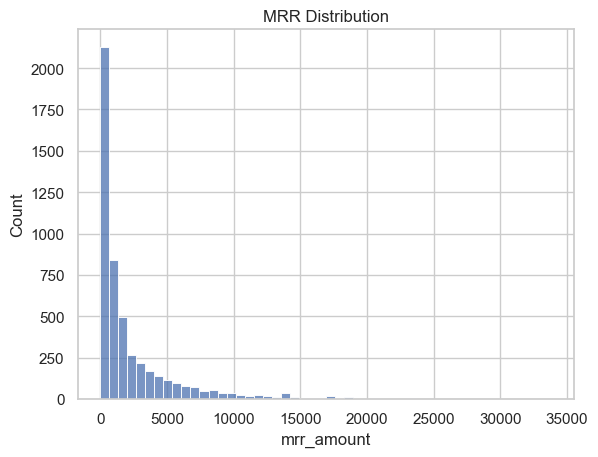

In [21]:
# MRR distribution
sns.histplot(subscriptions['mrr_amount'], bins=50)
plt.title('MRR Distribution')
plt.show()

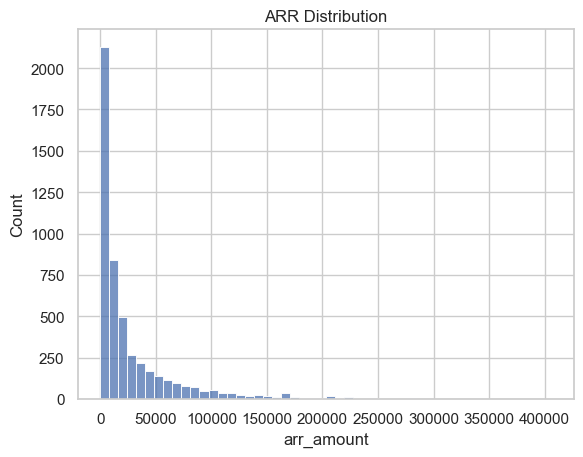

In [22]:
# ARR distribution
sns.histplot(subscriptions['arr_amount'], bins=50)
plt.title('ARR Distribution')
plt.show()

Revenue is right-skewed:
- Many low-paying users
- Few high-value users (long tail)

In [23]:
subscriptions['mrr_amount'].mean()

np.float64(2267.7494)

Average MRR provides a rough estimate of ARPU.

In [24]:
subscriptions['billing_frequency'].value_counts(normalize=True) * 100

billing_frequency
monthly    50.78
annual     49.22
Name: proportion, dtype: float64

Monthly and annual billing are evenly distributed.

### Churn Exploration

In [25]:
subscriptions['churn_flag'].mean()
subscriptions.groupby('plan_tier')['churn_flag'].mean()

plan_tier
Basic         0.094881
Enterprise    0.099826
Pro           0.096716
Name: churn_flag, dtype: float64

Churn rate is ~10% and consistent across plans.

In [26]:
churn_events['reason_code'].value_counts()

reason_code
features      114
support       104
budget        104
unknown        95
competitor     92
pricing        91
Name: count, dtype: int64

Most churn is related to product features rather than pricing.

### Feature usage

In [27]:
feature_usage['feature_name'].value_counts().head()

feature_name
feature_12    659
feature_32    659
feature_6     655
feature_17    651
feature_34    650
Name: count, dtype: int64

 Feature usage data is available and can be used later to analyze engagement vs churn.

### Data Relationships

In [28]:
df = subscriptions.merge(accounts, on='account_id', how='left')
df['account_id'].isnull().sum()

np.int64(0)

All subscriptions are successfully linked to accounts.

### Key Observations & Insights

- Multiple subscription records per account
- Revenue is concentrated in a small number of users
- Churn is moderate and not pricing-driven
- Channels are evenly distributed → good for CAC analysis
- Dataset supports full unit economics modeling

### Next Steps

- Data cleaning
- Marketing channel mapping
- Synthetic CAC generation
- SQL modeling
- Metrics calculation